This notebook plots the solutions. You can actually plot the progress while the solver is running to see if it makes sense.

Various imports:

In [1]:
%load_ext autoreload
%autoreload 2
# add path to code
import sys
sys.path.insert(0, '../source')
import numpy as np
import matplotlib.pyplot as plt
from load_lakes import lake_inventory
from netCDF4 import Dataset


In [2]:
outline = lake_inventory.loc[lake_inventory['name']=="Thw_124"]
neighbors = ['Thw_142', 'Thw_124', 'Thw_170', 'Thw_70']

In [3]:
x0 = float(outline.centroid.x.iloc[0])*1e3
y0 = float(outline.centroid.y.iloc[0])*1e3

# Select half-width L0 of box surrounding lake
L0 = 100*1000
xb_min = x0-1.5*L0
xb_max = x0+1.5*L0
yb_min = y0-1.25*L0
yb_max = y0+1.25*L0


# load and subset bedmachine data
bedmachine = Dataset('/Users/agstubbl/Desktop/bedmachine/BedMachineAntarctica-v3.nc')
x_bm = bedmachine['x'][:].data.astype(np.float64)
y_bm = bedmachine['y'][:].data.astype(np.float64)
bm_mask = bedmachine['mask'][:].data.astype(np.float64)
xb_sub = x_bm[(x_bm>=xb_min)&(x_bm<=xb_max)]
yb_sub = y_bm[(y_bm>=yb_min)&(y_bm<=yb_max)]
ind_x = np.arange(0,np.size(x_bm),1)
ind_y = np.arange(0,np.size(y_bm),1)
inds_x = ind_x[(x_bm>=xb_min)&(x_bm<=xb_max)]
inds_y = ind_y[(y_bm>=yb_min)&(y_bm<=yb_max)]
nx = np.size(inds_x)
ny = np.size(inds_y)
inds_xy = np.ix_(inds_y,inds_x)
mask_sub = bm_mask[inds_xy]

In [4]:
# # import the ATL15 data. edit the path to the data as appropriate
fn = '/Users/agstubbl/Desktop/ICESat-2/ATL15_A3_0321_01km_004_01.nc'
fn2 = '/Users/agstubbl/Desktop/ICESat-2/ATL15_A4_0321_01km_004_01.nc'
fn3 = '/Users/agstubbl/Desktop/ICESat-2/ATL15_A1_0321_01km_004_01.nc'
fn4 = '/Users/agstubbl/Desktop/ICESat-2/ATL15_A2_0321_01km_004_01.nc'

# define some variables
ds = Dataset(fn)
dsh = ds['delta_h']
dh = dsh['delta_h'][:]        # elevation change (m)
mask = dsh['ice_area'][:][-1,:,:].filled()
x_ = dsh['x'][:]               # x coordinate array (m)
y_ = dsh['y'][:]               # y coordinate array (m)


ds2 = Dataset(fn2)
dsh2 = ds2['delta_h']
dh2 = dsh2['delta_h'][:]        # elevation change (m)
mask2 = dsh2['ice_area'][:][-1,:,:].filled()
x2_ = dsh2['x'][:]               # x coordinate array (m)
y2_ = dsh2['y'][:] 

ds3 = Dataset(fn3)
dsh3 = ds3['delta_h']
dh3 = dsh3['delta_h'][:]        # elevation change (m)
mask3 = dsh3['ice_area'][:][-1,:,:].filled()
x3_ = dsh3['x'][:]               # x coordinate array (m)
y3_ = dsh3['y'][:] 

ds4 = Dataset(fn4)
dsh4 = ds4['delta_h']
dh4 = dsh4['delta_h'][:]        # elevation change (m)
mask4 = dsh4['ice_area'][:][-1,:,:].filled()
x4_ = dsh4['x'][:]               # x coordinate array (m)
y4_ = dsh4['y'][:] 

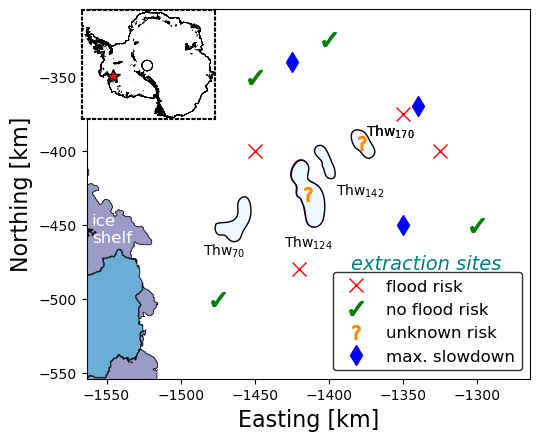

In [5]:
fig, ax = plt.subplots()
# plt.title('Hypothetical model-based site analysis',fontsize=18,fontweight='bold')
outline.plot(edgecolor='purple',facecolor='none',ax=plt.gca(),linewidth=1,zorder=200)
for name in neighbors:
    outline_nbr = lake_inventory.loc[lake_inventory['name']==name]
    outline_nbr.plot(edgecolor='k',facecolor='aliceblue',ax=plt.gca(),linewidth=1,zorder=200)

plt.contourf(xb_sub/1e3,yb_sub/1e3,mask_sub,cmap='Purples',levels=np.array([2.9,3.1]))
plt.contourf(xb_sub/1e3,yb_sub/1e3,mask_sub,cmap='Blues',levels=np.array([-0.1,0.1]))
plt.contour(xb_sub/1e3,yb_sub/1e3,mask_sub,colors='k',linewidths=0.5,levels=np.array([-0.1,0.1]))
plt.contour(xb_sub/1e3,yb_sub/1e3,mask_sub,colors='k',linewidths=0.5,levels=np.array([2.9,3.1]))

# random points
plt.plot([-1450],[-400],'rx',markersize=10,label=r'flood risk')
plt.plot([-1420],[-480],'rx',markersize=10)
plt.plot([-1325],[-400],'rx',markersize=10)
plt.plot([-1350],[-375],'rx',markersize=10)
plt.plot([-1450],[-350],'g',marker=r"$✓$",linewidth=0,markersize=10,label=r'no flood risk')
plt.plot([-1400],[-325],'g',marker=r"$✓$",markersize=10)
plt.plot([-1475],[-500],'g',marker=r"$✓$",markersize=10)
plt.plot([-1300],[-450],'g',marker=r"$✓$",markersize=10)
plt.plot([x0/1e3],[y0/1e3],linewidth=0,color='darkorange',marker=r"$?$",markersize=10,zorder=400,label=r'unknown risk')
plt.plot([-1350],[-450],'bd',markersize=10)
plt.plot([-1425],[-340],'bd',markersize=10)
plt.plot([-1340],[-370],'bd',markersize=10,label=r'max. slowdown')

outline_nbr = lake_inventory.loc[lake_inventory['name']=="Thw_170"]
x170 = float(outline_nbr.centroid.x.iloc[0])
y170 = float(outline_nbr.centroid.y.iloc[0])
plt.plot([x170],[y170],linewidth=0,color='darkorange',marker=r"$?$",markersize=10,zorder=400)

plt.annotate(r'Thw$_{70}$',xy=(-1485,-470))
plt.annotate(r'Thw$_{124}$',xy=(-1430,-465))
plt.annotate(r'Thw$_{142}$',xy=(-1395,-430))
plt.annotate(r'Thw$_{170}$',xy=(-1375,-390))
plt.annotate(r'Thw$_{170}$',xy=(-1375,-390))

plt.annotate(r'extraction sites',xy=(-1385,-480),fontweight='light',style='italic',color='teal',fontsize=14)


plt.annotate('ice\nshelf',xy=(-1560,-462),color='white',fontsize=12,zorder=1000)#,xytext=(-1525,-425))

ax_inset = plt.gca().inset_axes([-0.01, 0.70, 0.3, 0.3])
# ax_inset.axis('off')
ax_inset.set_xticks([])
ax_inset.set_yticks([])
for spine in ax_inset.spines.values():
    spine.set_linewidth(1.5)
    spine.set_linestyle(':')
ax_inset.contour(x_/1000, y_/1000, mask, colors='k', linewidths=0.5)
ax_inset.contour(x2_/1000, y2_/1000, mask2, colors='k', linewidths=0.5)
ax_inset.contour(x3_/1000, y3_/1000, mask3, colors='k', linewidths=0.5)
ax_inset.contour(x4_/1000, y4_/1000, mask4, colors='k', linewidths=0.5)
ax_inset.plot([x0/1e3],[y0/1e3],'*',color='red',markersize=10,markeredgecolor='k')
ax_inset.set_aspect('equal', 'box')
legend = plt.legend(fontsize=12,loc='lower right')#,title='extraction sites',title_fontsize=14)
frame = legend.get_frame()
frame.set_edgecolor('k')
ax.set_aspect('equal', 'box')
plt.xlabel(r'Easting [km]',fontsize=16)
plt.ylabel(r'Northing [km]',fontsize=16)
plt.savefig('fig3_draft',bbox_inches='tight')
plt.show()
plt.close()